# Taller: Diseño de una arquitectura LSTM para predicción de demanda energética

**Objetivo:** dada una ventana de *n* horas consecutivas de información multivariada, predecir la demanda eléctrica (MW) de la **siguiente hora** (`demanda_objetivo`).

**Contenido (se construye por etapas)**
1. Carga y auditoría de calidad *(Etapa 1)*
2. Reglas de limpieza justificadas *(Etapa 1)*
3. Análisis exploratorio *(Etapa 1)*
4. Split cronológico, normalización y ventanas *(Etapa 1)*
5. Arquitecturas A, B y C, entrenamiento con ventanas 12/24/48 *(Etapa 2)*
6. Métricas, gráficas y comparación *(Etapa 3)*
7. Preguntas de análisis *(Etapa 4)*
8. Despliegue en app web *(Etapa 5, sección 14)*

In [1]:
import sys, warnings, json
sys.path.insert(0, "src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as pp

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
SEED = 42
np.random.seed(SEED)
RUTA = "dataset_demanda_energia_LSTM_2025_2026.csv"

## 1. Carga y auditoría de calidad

In [2]:
crudo = pp.cargar_crudo(RUTA)
print(crudo.shape)
crudo.head()

(17550, 15)


,timestamp,demanda_mw,temperatura_c,humedad_pct,viento_kmh,radiacion_wm2,precipitacion_mm,precio_kwh,hora,dia_semana,fin_semana,festivo,mes,periodo_dia,demanda_objetivo
0,2025-05-11 08:00:00,578.27,19.94,52.31,12.98,445.51,0.00,29.5028,8,6,1,0,5,mañana,573.67
1,2026-07-21 05:00:00,734.79,21.51,61.71,16.04,0.00,4.56,18.9739,5,1,0,0,7,madrugada,758.59
2,2025-08-21 00:00:00,698.80,24.00,94.25,16.15,0.00,0.00,18.9476,0,3,0,0,8,madrugada,705.37
3,2025-08-18 17:00:00,787.40,24.39,63.25,6.15,83.32,0.00,31.7882,17,0,0,0,8,tarde,804.35
4,2026-04-19 09:00:00,522.11,19.65,55.63,14.01,556.14,0.00,35.2807,9,6,1,0,4,mañana,526.36


In [3]:
auditoria = pd.DataFrame({
    "nulos": crudo.isna().sum(),
    "% nulos": (crudo.isna().mean() * 100).round(2),
    "min": crudo.select_dtypes("number").min(),
    "max": crudo.select_dtypes("number").max(),
})
print("Duplicados exactos:", crudo.duplicated().sum())
print("Timestamps repetidos:", crudo.timestamp.duplicated().sum())
print("¿Orden cronológico?:", crudo.timestamp.is_monotonic_increasing)
print("Variantes de periodo_dia:", sorted(crudo.periodo_dia.unique()))
auditoria

Duplicados exactos: 30
Timestamps repetidos: 30
¿Orden cronológico?: False
Variantes de periodo_dia: [' noche ', 'MAÑANA', 'Mañana', 'TARDE', 'madrugada', 'mañana', 'noche', 'tarde']


,nulos,% nulos,min,max
demanda_mw,0,0.00,94.58,1776.21
demanda_objetivo,1,0.01,314.12,927.31
dia_semana,0,0.00,0.00,6.00
festivo,0,0.00,0.00,1.00
fin_semana,0,0.00,0.00,1.00
hora,0,0.00,0.00,23.00
humedad_pct,70,0.40,-2.35,129.69
mes,0,0.00,1.00,12.00
periodo_dia,0,0.00,NaN,NaN
precio_kwh,70,0.40,-4.17,79.58


**Problemas detectados** (coinciden con lo que advierte el enunciado):

| Problema | Evidencia |
|---|---|
| Desorden temporal | las filas no están ordenadas por `timestamp` |
| Duplicados | 30 filas exactamente repetidas |
| Faltantes | 70 nulos en temperatura, humedad, viento y precio; 1 en el objetivo |
| Inconsistencia de texto | `periodo_dia` con mayúsculas y espacios (`TARDE`, `Mañana`, ` noche `) |
| Anomalías | humedad > 100 %, viento y precio negativos, temperaturas de -23 °C y 54 °C, picos de demanda > 1700 MW |

## 2. Reglas de limpieza (y por qué)

Principio rector del taller: **no inventar valores**. Por eso nada se imputa ni se "suaviza": lo inválido se marca como `NaN` y las ventanas que lo contengan se excluyen del entrenamiento y la evaluación.

| # | Regla | Justificación |
|---|---|---|
| R1 | `strip` + minúsculas en `periodo_dia` | son la misma categoría escrita distinto; se pasa de 8 a 4 valores |
| R2 | Eliminar duplicados exactos | repetir una observación la sobre-pondera y puede filtrar filas de entrenamiento a validación |
| R3 | Ordenar por `timestamp` | una secuencia solo tiene sentido en orden temporal; se hace **antes** de crear ventanas |
| R4 | Verificar una fila por hora | tras R2 y R3 la serie queda completa (17 520 h); no hay huecos que rellenar |
| R5 | Valores fuera de rango físico → `NaN` | humedad ∈ [0,100], viento, precipitación, radiación y precio ≥ 0, temperatura ∈ [-10,45] °C; fuera de esos límites son errores de sensor, no clima |
| R6 | `demanda_mw` fuera de [300, 1000] MW → `NaN` | el objetivo (limpio) vive en 314-927 MW; los picos de 1100-1776 MW aparecen en `demanda_mw` pero **no** en el objetivo, por lo que son errores de medición |
| R7 | Ventanas con algún `NaN` se descartan | evita imputar; el costo es perder algunas ventanas |
| R8 | Fila final sin objetivo se descarta | 2026-12-31 23:00 no tiene "hora siguiente" |

**Variables usadas como entrada** (15 por hora): las 7 continuas (incluida la demanda pasada), hora/día/mes en codificación **cíclica** seno-coseno (para que 23 h y 0 h queden cerca), `fin_semana` y `festivo`.
`periodo_dia` se limpia pero se excluye: es una función exacta de `hora` (información redundante). `demanda_objetivo` **nunca** es entrada: es la respuesta.

In [4]:
df, rep = pp.limpiar(crudo)
print(json.dumps(rep, indent=2, ensure_ascii=False))
df = pp.agregar_ciclicas(df)
print("\nPeriodos:", df.periodo_dia.unique(), "| filas:", len(df),
      "| rango:", df.timestamp.min(), "->", df.timestamp.max())

{
  "filas_crudas": 17550,
  "periodo_dia_variantes_antes": 8,
  "periodo_dia_variantes_despues": 4,
  "desordenado": true,
  "duplicados": 30,
  "timestamps_repetidos_restantes": 0,
  "horas_faltantes": 0,
  "nan_originales": {
    "demanda_mw": 0,
    "temperatura_c": 70,
    "humedad_pct": 70,
    "viento_kmh": 70,
    "radiacion_wm2": 0,
    "precipitacion_mm": 0,
    "precio_kwh": 70
  },
  "anomalias": {
    "demanda_mw": 23,
    "temperatura_c": 13,
    "humedad_pct": 9,
    "viento_kmh": 14,
    "radiacion_wm2": 0,
    "precipitacion_mm": 0,
    "precio_kwh": 3
  }
}

Periodos: <ArrowStringArray>
['madrugada', 'mañana', 'tarde', 'noche']
Length: 4, dtype: str | filas: 17520 | rango: 2025-01-01 00:00:00 -> 2026-12-31 23:00:00


In [5]:
# Verificación de que la regla R6 apunta a errores y no a demanda real:
# el objetivo es la demanda de t+1, así que en una hora normal demanda_mw(t+1) == objetivo(t).
chk = (crudo.sort_values("timestamp").drop_duplicates().set_index("timestamp"))
dif = (chk.demanda_mw.shift(-1) - chk.demanda_objetivo).abs()
print("Coincidencia demanda(t+1) vs objetivo(t):", f"{(dif < 0.01).mean():.2%}")
print("Rango del objetivo:", chk.demanda_objetivo.min(), "-", chk.demanda_objetivo.max())

Coincidencia demanda(t+1) vs objetivo(t): 99.77%
Rango del objetivo: 314.12 - 927.31


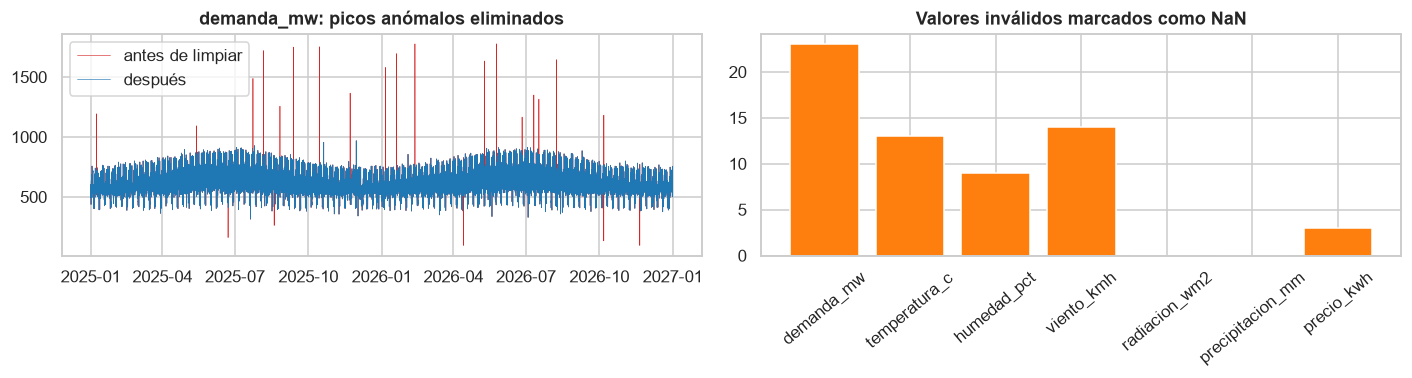

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
cr = crudo.sort_values("timestamp").drop_duplicates()
ax[0].plot(cr.timestamp, cr.demanda_mw, lw=.4, color="tab:red", label="antes de limpiar")
ax[0].plot(df.timestamp, df.demanda_mw, lw=.4, color="tab:blue", label="después")
ax[0].set_title("demanda_mw: picos anómalos eliminados"); ax[0].legend()
ax[1].bar(rep["anomalias"].keys(), rep["anomalias"].values(), color="tab:orange")
ax[1].set_title("Valores inválidos marcados como NaN"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 3. Análisis exploratorio

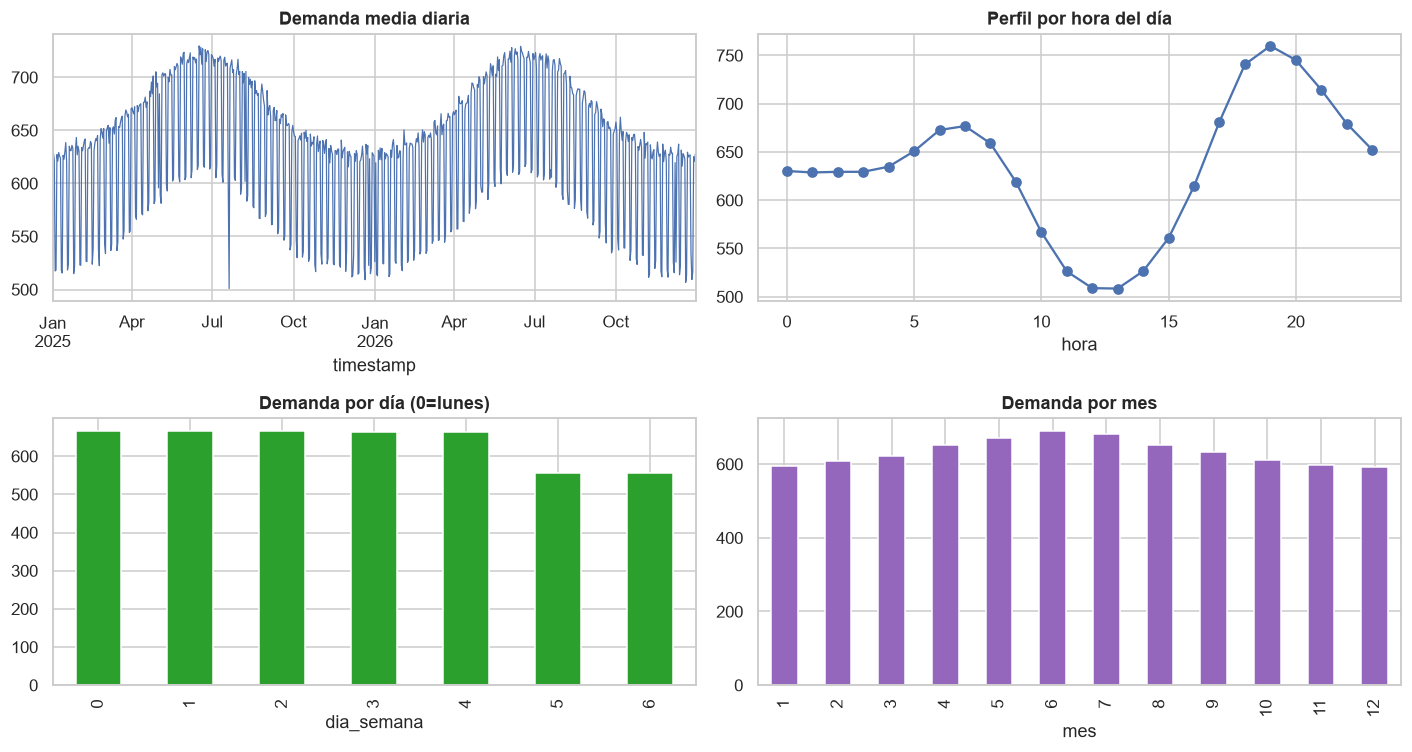

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
d = df.set_index("timestamp")
d.demanda_mw.resample("D").mean().plot(ax=ax[0,0], lw=.8); ax[0,0].set_title("Demanda media diaria")
df.groupby("hora").demanda_mw.mean().plot(ax=ax[0,1], marker="o"); ax[0,1].set_title("Perfil por hora del día")
df.groupby("dia_semana").demanda_mw.mean().plot.bar(ax=ax[1,0], color="tab:green"); ax[1,0].set_title("Demanda por día (0=lunes)")
df.groupby("mes").demanda_mw.mean().plot.bar(ax=ax[1,1], color="tab:purple"); ax[1,1].set_title("Demanda por mes")
plt.tight_layout(); plt.show()

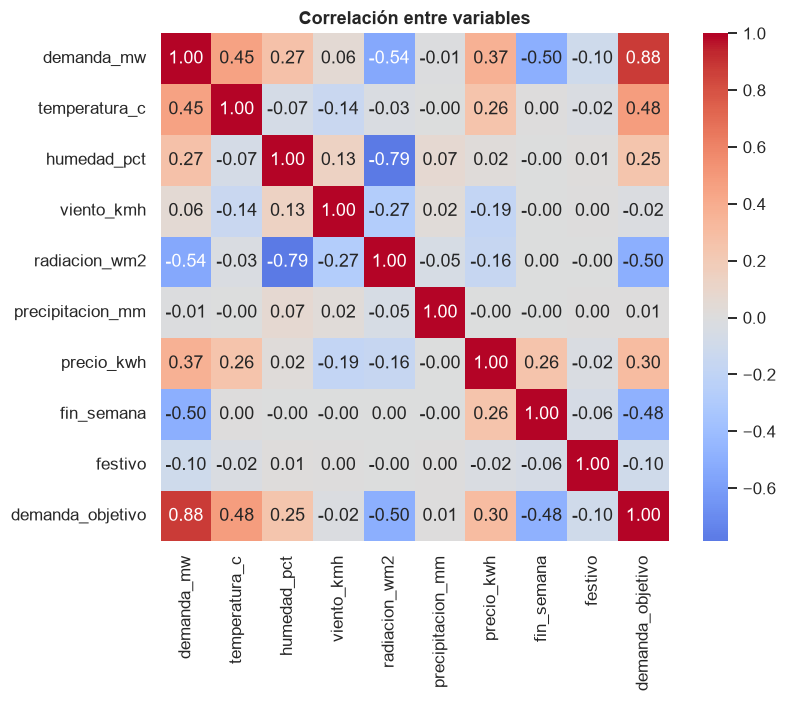

demanda_mw          0.877
radiacion_wm2      -0.503
fin_semana         -0.485
temperatura_c       0.476
precio_kwh          0.304
humedad_pct         0.249
festivo            -0.100
viento_kmh         -0.015
precipitacion_mm    0.007
Name: demanda_objetivo, dtype: float64


In [8]:
corr = df[pp.CONTINUAS + ["fin_semana", "festivo", "demanda_objetivo"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlación entre variables"); plt.show()
print(corr["demanda_objetivo"].drop("demanda_objetivo").sort_values(key=abs, ascending=False).round(3))

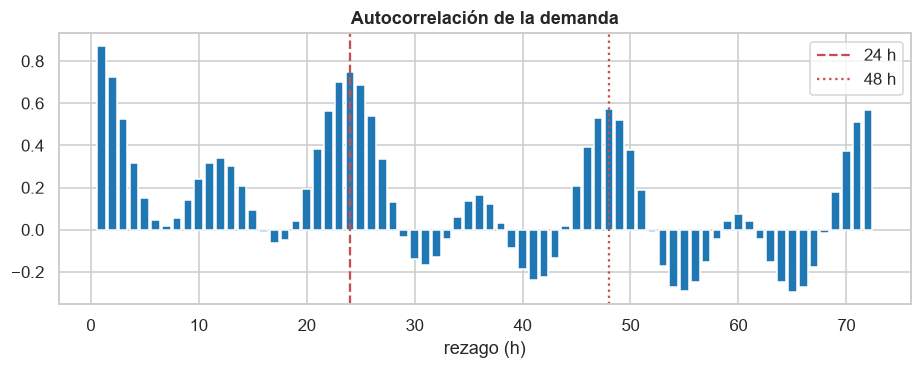

In [9]:
# Autocorrelación de la demanda: justifica el uso de ventanas de 12-48 h
x = df.demanda_mw.interpolate()   # solo para esta gráfica exploratoria, NO se usa en el modelo
ac = [x.autocorr(l) for l in range(1, 73)]
plt.figure(figsize=(10, 3.2)); plt.bar(range(1, 73), ac, color="tab:blue")
plt.axvline(24, color="r", ls="--", label="24 h"); plt.axvline(48, color="r", ls=":", label="48 h")
plt.xlabel("rezago (h)"); plt.title("Autocorrelación de la demanda"); plt.legend(); plt.show()

## 4. Split cronológico, normalización y ventanas

* **Split 70 / 15 / 15 por orden temporal** (sin `train_test_split` aleatorio): entrenamiento primero, luego validación (para Early Stopping y selección) y al final prueba, que nunca se toca hasta evaluar.
* **Normalización z-score** con media y desviación calculadas **solo en entrenamiento**, aplicadas luego a validación y prueba.
* **Ventanas:** para cada hora *t*, la entrada son las horas *[t-n+1 … t]* y el objetivo es la demanda de *t+1*. Cada ventana se asigna al conjunto según la fecha de *t*, de modo que el objetivo de validación/prueba nunca se ve en entrenamiento. Las horas anteriores de la entrada son pasado, no hay fuga.

In [10]:
df = df.reset_index(drop=True)
i_tr, i_va = pp.split_cronologico(len(df))
cortes = {"entrenamiento": (0, i_tr), "validación": (i_tr, i_va), "prueba": (i_va, len(df))}
for k, (a, b) in cortes.items():
    print(f"{k:14s} {df.timestamp[a]}  ->  {df.timestamp[b-1]}   ({b-a} h)")

esc = pp.Escalador().ajustar(df.iloc[:i_tr])          # SOLO entrenamiento
X = esc.x(df); y = esc.y(df[pp.TARGET])
print("\nMedia/desv. de entrenamiento:")
print(pd.DataFrame({"media": esc.media, "std": esc.std}).round(2))

entrenamiento  2025-01-01 00:00:00  ->  2026-05-26 23:00:00   (12264 h)
validación     2026-05-27 00:00:00  ->  2026-09-13 11:00:00   (2628 h)
prueba         2026-09-13 12:00:00  ->  2026-12-31 23:00:00   (2628 h)

Media/desv. de entrenamiento:
                   media     std
demanda_mw        632.38   97.08
temperatura_c      18.82    5.59
humedad_pct        72.21   14.79
viento_kmh         11.03    4.70
radiacion_wm2     201.89  257.08
precipitacion_mm    0.95    2.09
precio_kwh         24.62    5.41


In [11]:
VENTANAS = [12, 24, 48]
datos = {}
for n in VENTANAS:
    datos[n] = {nom: pp.crear_ventanas(X, y, n, a, b) for nom, (a, b) in cortes.items()}

# Para comparar ventanas de forma justa, la evaluación usa un conjunto común:
# los instantes t válidos para n=48 (toda ventana válida de 48 h lo es también de 12 y 24 h).
idx_comun = {nom: datos[48][nom][2] for nom in cortes}

filas = []
for n in VENTANAS:
    f = {"ventana": n}
    for nom in cortes:
        f[nom] = len(datos[n][nom][2])
    filas.append(f)
resumen = pd.DataFrame(filas).set_index("ventana")
resumen.loc["común (n=48)"] = [len(idx_comun[k]) for k in cortes]
print("Ventanas disponibles tras descartar las que contienen NaN:")
resumen

Ventanas disponibles tras descartar las que contienen NaN:


,entrenamiento,validación,prueba
ventana,,,
12,9686,2051,2093
24,7526,1605,1664
48,4504,964,1042
común (n=48),4504,964,1042


**Nota sobre la pérdida de ventanas.** Cada valor inválido invalida las *n* ventanas que lo contienen, por eso la ventana de 48 h conserva menos muestras que la de 12 h. Es el precio de no inventar valores. Para que la comparación entre ventanas sea justa, en la Etapa 3 todos los modelos se evaluarán además sobre el **conjunto común** de instantes de prueba.

In [12]:
# Comprobaciones anti-fuga
assert df.timestamp.is_monotonic_increasing and not df.timestamp.duplicated().any()
assert pp.TARGET not in pp.FEATURES
for n in VENTANAS:
    assert datos[n]["entrenamiento"][2].max() < i_tr <= datos[n]["validación"][2].min()
    assert datos[n]["validación"][2].max() < i_va <= datos[n]["prueba"][2].min()
Xtr = datos[24]["entrenamiento"][0]
print("Entradas:", pp.FEATURES)
print("Forma (muestras, pasos, variables):", Xtr.shape)
print("Variables continuas en train — media≈0 y std≈1:",
      np.nanmean(Xtr[:, :, :pp.N_CONT]).round(3), np.nanstd(Xtr[:, :, :pp.N_CONT]).round(3))
print("OK: sin fuga temporal.")

Entradas: ['demanda_mw', 'temperatura_c', 'humedad_pct', 'viento_kmh', 'radiacion_wm2', 'precipitacion_mm', 'precio_kwh', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'fin_semana', 'festivo']
Forma (muestras, pasos, variables): (7526, 24, 15)
Variables continuas en train — media≈0 y std≈1: 0.004 1.001
OK: sin fuga temporal.


In [13]:
# Guardar artefactos para las siguientes etapas y la app
import joblib, os
os.makedirs("artefactos", exist_ok=True)
joblib.dump({"datos": datos, "idx_comun": idx_comun, "cortes": cortes, "escalador": esc.a_dict(),
             "features": pp.FEATURES, "ventanas": VENTANAS}, "artefactos/datos_ventanas.joblib")
df.to_csv("artefactos/dataset_limpio.csv", index=False)
print("Artefactos guardados.")

Artefactos guardados.


## 5. Diseño de las arquitecturas

Se comparan tres alternativas. Todas reciben una ventana `(n horas × 15 variables)` y producen un único valor: la demanda normalizada de la hora siguiente.

| | Arquitectura | Diseño | Por qué |
|---|---|---|---|
| **A** | LSTM base | `LSTM(32)` → `Dense(1)` | Línea de referencia: la red recurrente más simple. Si un modelo más complejo no la supera, la complejidad no se justifica. |
| **B** | LSTM profunda | `LSTM(64)` → `Dropout(0.2)` → `LSTM(32)` → `Dropout(0.2)` → `Dense(16)` → `Dense(1)` | Dos capas apiladas aprenden representaciones jerárquicas (la primera, patrones horarios; la segunda, tendencias más lentas). El Dropout controla el sobreajuste que trae la mayor capacidad. |
| **C** | CNN-LSTM (propuesta) | `Conv1D(32, k=3, causal)` → `LSTM(48)` → `Dropout(0.2)` → `Dense(16)` → `Dense(1)` | La convolución detecta cambios locales (rampas de pocas horas, picos de radiación o temperatura) y reduce el ruido antes de la LSTM, que se centra en la dependencia temporal larga. Es causal: cada paso solo ve horas anteriores, sin información futura. Menos parámetros que B. |

**Configuración común de entrenamiento** (para que la comparación sea justa):
- Pérdida **MSE**, optimizador **Adam** (lr = 1e-3), lotes de 64, hasta 80 épocas.
- **Early Stopping** sobre la pérdida de validación (paciencia 10, restaura los mejores pesos).
- **ReduceLROnPlateau**: reduce el learning rate a la mitad si la validación se estanca 4 épocas.
- Semilla fija. Los lotes se mezclan *dentro* de entrenamiento (cada muestra ya es una ventana completa, así que barajar no rompe el orden temporal ni mezcla conjuntos).

In [14]:
import os, time, joblib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf, keras
import modelos as mdl

keras.utils.set_random_seed(SEED)
N_FEAT = len(pp.FEATURES)
for k, f in mdl.ARQUITECTURAS.items():
    m = f(24, N_FEAT)
    print(f"{m.name:18s} parámetros: {m.count_params():>7,}")
mdl.modelo_B(24, N_FEAT).summary()

A_LSTM_base        parámetros:   6,177
B_LSTM_profunda    parámetros:  33,441
C_CNN_LSTM         parámetros:  17,825


Model: "B_LSTM_profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento: 3 arquitecturas × 3 ventanas = 9 modelos
Cada modelo se entrena con las ventanas de su propio tamaño (`datos[n]`), usando validación únicamente para Early Stopping. **El conjunto de prueba no se usa en ningún momento del entrenamiento.**

In [15]:
os.makedirs("modelos", exist_ok=True)
def entrenar(arq, n, max_epocas=80, batch=64):
    keras.utils.set_random_seed(SEED)
    Xtr, ytr, _ = datos[n]["entrenamiento"]
    Xva, yva, _ = datos[n]["validación"]
    m = mdl.ARQUITECTURAS[arq](n, N_FEAT)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
          keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)]
    t0 = time.time()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=max_epocas, batch_size=batch,
              shuffle=True, callbacks=cb, verbose=0)
    hist = h.history
    mejor = int(np.argmin(hist["val_loss"]))
    info = {"arq": arq, "ventana": n, "epocas_ejecutadas": len(hist["loss"]), "mejor_epoca": mejor + 1,
            "loss_train_mejor": hist["loss"][mejor], "loss_val_mejor": hist["val_loss"][mejor],
            "parametros": m.count_params(), "segundos": time.time() - t0}
    m.save(f"modelos/{arq}_w{n}.keras")
    return info, hist

# REENTRENAR = True vuelve a entrenar los 9 modelos (~10 min en CPU).
# Con False se cargan los modelos e historiales ya guardados (resultados idénticos).
REENTRENAR = False
ya_entrenado = os.path.exists("artefactos/entrenamiento.joblib") and all(
    os.path.exists(f"modelos/{a}_w{n}.keras") for a in "ABC" for n in VENTANAS)

if REENTRENAR or not ya_entrenado:
    resultados, historiales = [], {}
    for arq in "ABC":
        for n in VENTANAS:
            info, hist = entrenar(arq, n)
            resultados.append(info); historiales[f"{arq}_w{n}"] = hist
    joblib.dump({"historiales": historiales, "resultados": resultados}, "artefactos/entrenamiento.joblib")
else:
    g = joblib.load("artefactos/entrenamiento.joblib")
    resultados, historiales = g["resultados"], g["historiales"]
    print("Modelos cargados desde disco (REENTRENAR=False).")
for info in resultados:
    print(f"{info['arq']} | ventana {info['ventana']:2d} | épocas {info['epocas_ejecutadas']:2d} "
          f"(mejor {info['mejor_epoca']:2d}) | val_loss {info['loss_val_mejor']:.4f} | {info['segundos']:.0f}s")

Modelos cargados desde disco (REENTRENAR=False).
A | ventana 12 | épocas 60 (mejor 50) | val_loss 0.0689 | 50s
A | ventana 24 | épocas 45 (mejor 35) | val_loss 0.0725 | 45s
A | ventana 48 | épocas 55 (mejor 45) | val_loss 0.0737 | 59s
B | ventana 12 | épocas 54 (mejor 44) | val_loss 0.0695 | 106s
B | ventana 24 | épocas 42 (mejor 32) | val_loss 0.0740 | 99s
B | ventana 48 | épocas 55 (mejor 45) | val_loss 0.0765 | 137s
C | ventana 12 | épocas 56 (mejor 46) | val_loss 0.0710 | 65s
C | ventana 24 | épocas 66 (mejor 56) | val_loss 0.0743 | 90s
C | ventana 48 | épocas 51 (mejor 41) | val_loss 0.0759 | 72s


In [16]:
res = pd.DataFrame(resultados)
res["gap (val-train)"] = res.loss_val_mejor - res.loss_train_mejor
res.round(4)

,arq,ventana,epocas_ejecutadas,mejor_epoca,loss_train_mejor,loss_val_mejor,parametros,segundos,gap (val-train)
0,A,12,60,50,0.0583,0.0689,6177,49.7946,0.0106
1,A,24,45,35,0.0628,0.0725,6177,45.1892,0.0096
2,A,48,55,45,0.0613,0.0737,6177,58.5274,0.0124
3,B,12,54,44,0.0708,0.0695,33441,106.4525,-0.0014
4,B,24,42,32,0.0810,0.0740,33441,98.9429,-0.0070
5,B,48,55,45,0.0801,0.0765,33441,136.9567,-0.0036
6,C,12,56,46,0.0672,0.0710,17825,64.7128,0.0038
7,C,24,66,56,0.0711,0.0743,17825,90.0674,0.0031
8,C,48,51,41,0.0730,0.0759,17825,71.7139,0.0029


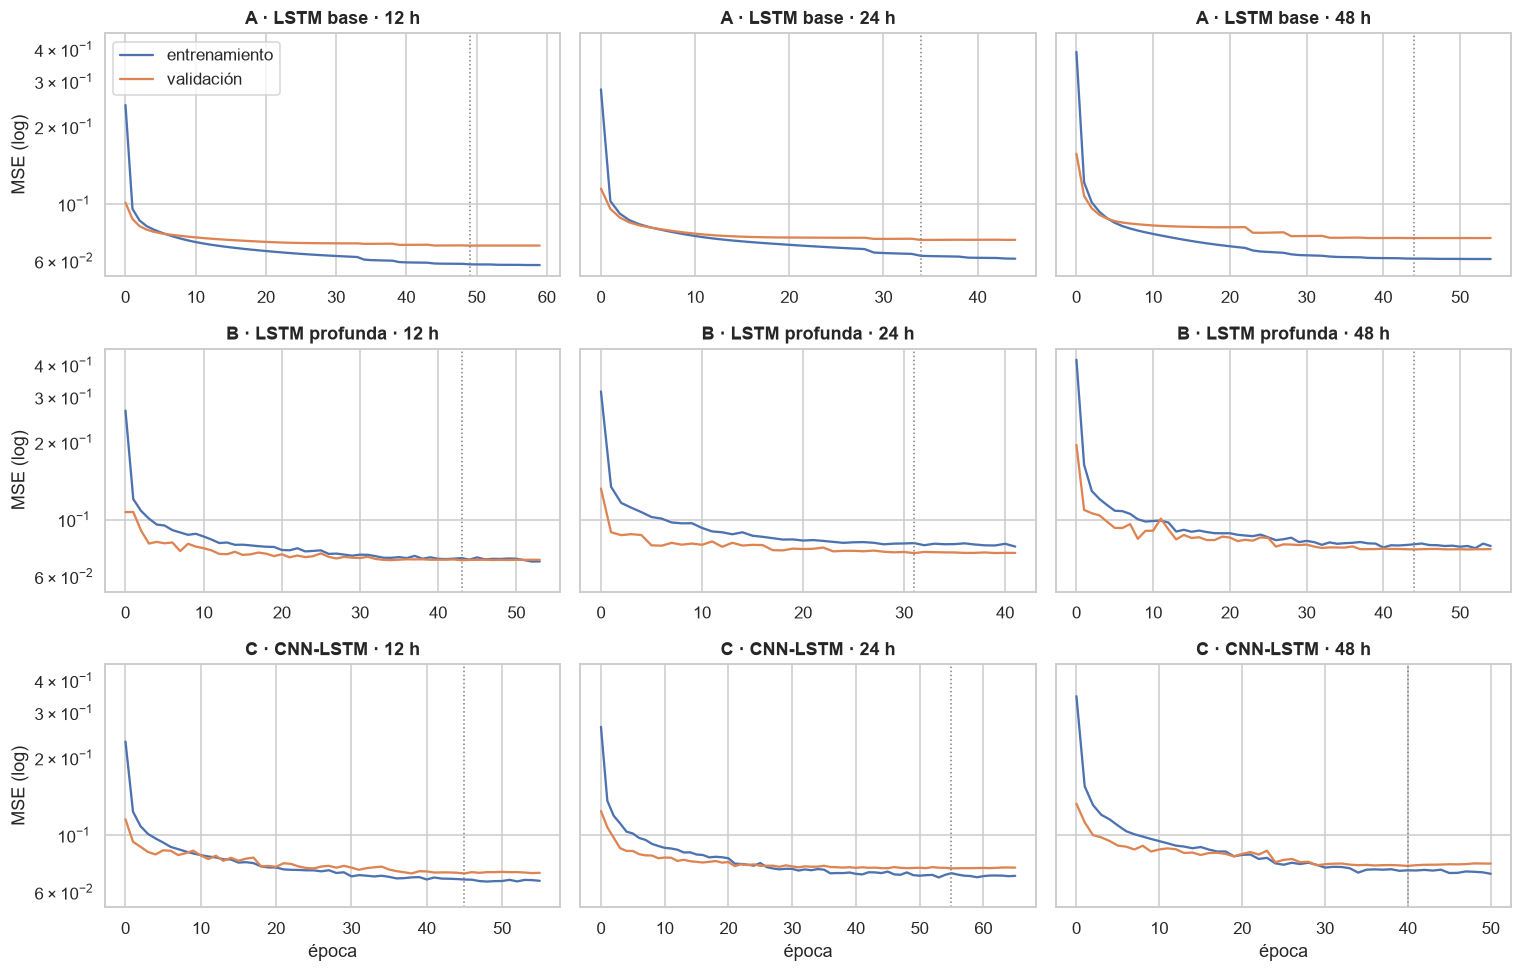

In [17]:
# Curvas de pérdida (MSE sobre datos normalizados) de los 9 modelos
nombres = {"A": "A · LSTM base", "B": "B · LSTM profunda", "C": "C · CNN-LSTM"}
fig, ax = plt.subplots(3, 3, figsize=(14, 9), sharey=True)
for i, arq in enumerate("ABC"):
    for j, n in enumerate(VENTANAS):
        h = historiales[f"{arq}_w{n}"]; a = ax[i, j]
        a.plot(h["loss"], label="entrenamiento"); a.plot(h["val_loss"], label="validación")
        a.axvline(int(np.argmin(h["val_loss"])), color="gray", ls=":", lw=1)
        a.set_title(f"{nombres[arq]} · {n} h"); a.set_yscale("log")
        if i == 2: a.set_xlabel("época")
        if j == 0: a.set_ylabel("MSE (log)")
ax[0, 0].legend(); plt.tight_layout(); plt.show()

**Lectura preliminar de las curvas** (las métricas finales sobre prueba —MAE, MSE, RMSE, MAPE y R²— llegan en la Etapa 3):

* **Todas convergen** en 40-66 épocas y Early Stopping detiene el entrenamiento 10 épocas después del mejor punto de validación (línea punteada), restaurando esos pesos.
* **A (sin Dropout)** es la única donde la pérdida de entrenamiento sigue bajando mientras la de validación se aplana: aparece una brecha pequeña pero sistemática (≈0.010-0.012), un **sobreajuste leve**.
* **B y C (con Dropout)** muestran brecha casi nula o incluso negativa (validación ≤ entrenamiento). Esto no es un error: el Dropout está activo solo al calcular la pérdida de entrenamiento y se apaga al validar, así que la red "completa" rinde mejor que la red con neuronas apagadas.
* **Ventana:** en validación, 12 h obtiene la menor pérdida en las tres arquitecturas. Ojo: con 48 h hay menos muestras de entrenamiento (4 504 vs 9 686) por las ventanas descartadas, así que la comparación definitiva se hará sobre el conjunto de prueba común.
* **Más parámetros no implicó mejor resultado:** B (33 441 parámetros) no supera a A (6 177) en validación.


## 7. Evaluación sobre el conjunto de prueba

Todas las métricas están en **MW** (se des-normaliza con los parámetros de entrenamiento):

* **MAE** = media del valor absoluto de (real − predicho): error típico en MW, fácil de interpretar.
* **MSE** = media de (real − predicho)²: castiga más los errores grandes.
* **RMSE** = √MSE: mismo castigo que MSE pero en MW.
* **MAPE** = media del valor absoluto de (real − predicho) / real × 100: error relativo en %.
* **R²** = 1 − SSE/SST: fracción de la variabilidad de la demanda que explica el modelo (1 = perfecto).

**Conjunto común de prueba.** Para comparar ventanas de forma justa, la tabla principal evalúa los 9 modelos sobre los **mismos instantes** de prueba (los válidos para la ventana de 48 h). Se incluye como referencia un modelo ingenuo de **persistencia** (*la demanda de la próxima hora será igual a la actual*): un modelo útil debe superarlo con claridad.

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import logging
tf.get_logger().setLevel(logging.ERROR)

def con_huecos(idx, *series):
    """Inserta NaN donde los instantes no son consecutivos, para no unir huecos con líneas."""
    full = np.arange(idx[0], idx[-1] + 1)
    pos = np.searchsorted(full, idx)
    out = [df.timestamp.to_numpy()[full]]
    for s in series:
        v = np.full(len(full), np.nan); v[pos] = s; out.append(v)
    return out

modelos = {f"{a}_w{n}": keras.models.load_model(f"modelos/{a}_w{n}.keras") for a in "ABC" for n in VENTANAS}
NOMBRE = {"A": "A · LSTM base", "B": "B · LSTM profunda", "C": "C · CNN-LSTM"}
COLOR = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a"}     # fijo por arquitectura
TINTA, GRIS = "#0b0b0b", "#898781"
info_ent = {f"{r['arq']}_w{r['ventana']}": r for r in resultados}
dem_real = df[pp.TARGET].to_numpy()                          # objetivo en MW (sin escalar)

def metricas(y, p):
    mse = mean_squared_error(y, p)
    return {"MAE": mean_absolute_error(y, p), "MSE": mse, "RMSE": np.sqrt(mse),
            "MAPE": np.mean(np.abs((y - p) / y)) * 100, "R²": r2_score(y, p)}

def predecir(clave, conjunto, solo_idx=None):
    """Predicción en MW de un modelo sobre un conjunto; opcionalmente filtra instantes t."""
    n = int(clave.split("_w")[1])
    Xw, _, it = datos[n][conjunto]
    if solo_idx is not None:
        m = np.isin(it, solo_idx); Xw, it = Xw[m], it[m]
    p = esc.y_inverso(modelos[clave].predict(Xw, batch_size=512, verbose=0).ravel())
    return it, p

filas, pred_test = [], {}
for clave in modelos:
    it, p = predecir(clave, "prueba", idx_comun["prueba"])
    pred_test[clave] = (it, p)
    r = info_ent[clave]
    filas.append({"Modelo": NOMBRE[r["arq"]], "Ventana": r["ventana"], **metricas(dem_real[it], p),
                  "Épocas": r["epocas_ejecutadas"], "Mejor época": r["mejor_epoca"]})

# Persistencia (sin entrenamiento): ŷ(t+1) = demanda_mw(t)
it = idx_comun["prueba"]
filas.append({"Modelo": "Persistencia (referencia)", "Ventana": 1,
              **metricas(dem_real[it], df.demanda_mw.to_numpy()[it]), "Épocas": 0, "Mejor época": 0})
tabla = pd.DataFrame(filas)
print(f"Instantes de prueba comunes: {len(it)}  ({df.timestamp[it[0]].date()} a {df.timestamp[it[-1]].date()})")
tabla.style.format({"MAE": "{:.2f}", "MSE": "{:.1f}", "RMSE": "{:.2f}", "MAPE": "{:.2f}%", "R²": "{:.4f}"}) \
     .highlight_min(subset=["MAE", "MSE", "RMSE", "MAPE"], color="#cde2fb") \
     .highlight_max(subset=["R²"], color="#cde2fb").hide(axis="index")

Instantes de prueba comunes: 1042  (2026-09-26 a 2026-12-31)


Modelo,Ventana,MAE,MSE,RMSE,MAPE,R²,Épocas,Mejor época
A · LSTM base,12,19.86,624.6,24.99,3.43%,0.9037,60,50
A · LSTM base,24,20.12,652.6,25.55,3.47%,0.8994,45,35
A · LSTM base,48,21.06,718.4,26.80,3.63%,0.8893,55,45
B · LSTM profunda,12,19.43,613.5,24.77,3.37%,0.9054,54,44
B · LSTM profunda,24,20.05,659.7,25.69,3.47%,0.8983,42,32
B · LSTM profunda,48,20.68,681.4,26.10,3.58%,0.8950,55,45
C · CNN-LSTM,12,19.75,641.8,25.33,3.42%,0.9011,56,46
C · CNN-LSTM,24,19.86,650.8,25.51,3.43%,0.8997,66,56
C · CNN-LSTM,48,21.28,744.6,27.29,3.68%,0.8852,51,41
Persistencia (referencia),1,35.50,1963.3,44.31,6.07%,0.6974,0,0


In [19]:
# Tabla complementaria: cada modelo sobre TODAS sus ventanas válidas de prueba
# (más muestras para 12 h y 24 h; no es directamente comparable entre ventanas)
filas = []
for clave in modelos:
    it, p = predecir(clave, "prueba")
    r = info_ent[clave]
    filas.append({"Modelo": NOMBRE[r["arq"]], "Ventana": r["ventana"], "n prueba": len(it),
                  **metricas(dem_real[it], p), "Épocas": r["epocas_ejecutadas"]})
pd.DataFrame(filas).round({"MAE": 2, "MSE": 1, "RMSE": 2, "MAPE": 2, "R²": 4})

,Modelo,Ventana,n prueba,MAE,MSE,RMSE,MAPE,R²,Épocas
0,A · LSTM base,12,2093,19.91,625.4,25.01,3.40,0.9076,60
1,A · LSTM base,24,1664,20.30,661.1,25.71,3.47,0.9023,45
2,A · LSTM base,48,1042,21.06,718.4,26.80,3.63,0.8893,55
3,B · LSTM profunda,12,2093,19.47,612.1,24.74,3.34,0.9096,54
4,B · LSTM profunda,24,1664,20.25,664.7,25.78,3.47,0.9017,42
5,B · LSTM profunda,48,1042,20.68,681.4,26.10,3.58,0.8950,55
6,C · CNN-LSTM,12,2093,19.68,626.3,25.03,3.37,0.9075,56
7,C · CNN-LSTM,24,1664,20.23,667.3,25.83,3.47,0.9014,66
8,C · CNN-LSTM,48,1042,21.28,744.6,27.29,3.68,0.8852,51


**Lectura de la tabla**

* **Las 9 LSTM superan ampliamente a la persistencia:** RMSE de ~25-27 MW frente a 44 MW (≈ −43 %) y R² de 0.89-0.91 frente a 0.70. El modelo aprende algo más que "repetir la última hora": usa el perfil diario, el calendario y el clima.
* **Error típico ≈ 20 MW (MAPE ≈ 3.4 %)** sobre una demanda media de ~600 MW.
* **Ventana:** 12 h es la mejor en las tres arquitecturas y 48 h la peor. El patrón diario ya se ve en las codificaciones cíclicas de hora/día, y las últimas horas contienen casi toda la información útil; alargar la ventana añade entradas poco informativas y, por las ventanas descartadas, reduce las muestras de entrenamiento (9 686 → 4 504).
* **Arquitecturas:** las diferencias entre A, B y C son pequeñas (≤ 0.6 MW de RMSE en la misma ventana), menores que la variación que produce cambiar la ventana. La complejidad extra de B y C apenas se traduce en mejora.

### Selección del modelo
El modelo final se elige con **validación**, no con prueba: elegir mirando prueba convertiría a la prueba en otro conjunto de ajuste y la estimación del error dejaría de ser honesta.

In [20]:
rmse_val = {}
for clave in modelos:                     # validación sobre instantes comunes (justo entre ventanas)
    iv, pv = predecir(clave, "validación", idx_comun["validación"])
    rmse_val[clave] = np.sqrt(mean_squared_error(dem_real[iv], pv))
print("RMSE de validación (MW, instantes comunes):")
print(pd.Series(rmse_val).sort_values().round(2).to_string())
MEJOR = min(rmse_val, key=rmse_val.get)
sel = info_ent[MEJOR]
print(f"\nModelo seleccionado por validación: {NOMBRE[sel['arq']]} con ventana de {sel['ventana']} h")
tabla[(tabla.Modelo == NOMBRE[sel["arq"]]) & (tabla.Ventana == sel["ventana"])].round(4)

RMSE de validación (MW, instantes comunes):
A_w12    25.26
A_w24    25.33
B_w12    25.50
C_w12    25.71
C_w24    25.91
B_w24    26.24
A_w48    26.31
C_w48    26.70
B_w48    26.81

Modelo seleccionado por validación: A · LSTM base con ventana de 12 h


,Modelo,Ventana,MAE,MSE,RMSE,MAPE,R²,Épocas,Mejor época
0,A · LSTM base,12,19.8565,624.5809,24.9916,3.4289,0.9037,60,50


## 8. Gráficas

### 8.1 Comparación de modelos

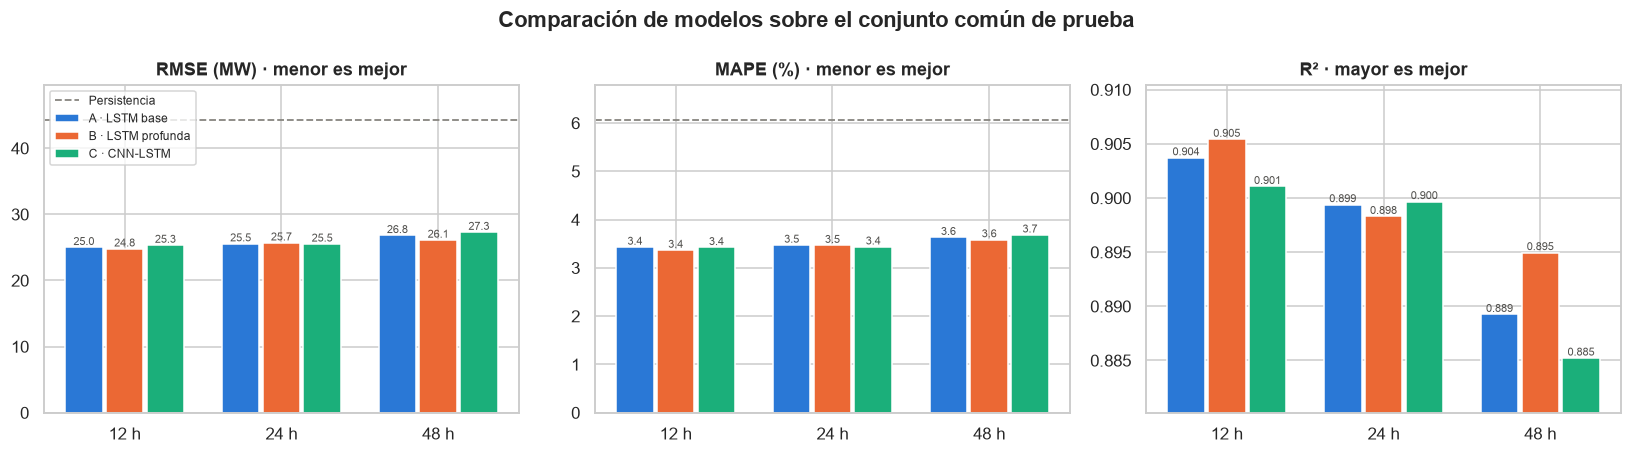

In [21]:
t9 = tabla[tabla.Modelo != "Persistencia (referencia)"]
pers = tabla[tabla.Modelo == "Persistencia (referencia)"].iloc[0]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ancho = 0.26
for k, (met, titulo) in enumerate([("RMSE", "RMSE (MW) · menor es mejor"),
                                   ("MAPE", "MAPE (%) · menor es mejor"),
                                   ("R²", "R² · mayor es mejor")]):
    a = ax[k]
    for j, arq in enumerate("ABC"):
        v = t9[t9.Modelo == NOMBRE[arq]].sort_values("Ventana")[met].to_numpy()
        x = np.arange(3) + (j - 1) * ancho
        a.bar(x, v, ancho * 0.92, color=COLOR[arq], label=NOMBRE[arq])
        for xi, vi in zip(x, v):
            a.text(xi, vi, f"{vi:.3f}" if met == "R²" else f"{vi:.1f}", ha="center", va="bottom",
                   fontsize=7.5, color="#52514e")
    a.axhline(pers[met], color=GRIS, ls="--", lw=1.2, label="Persistencia")
    a.set_xticks(range(3), [f"{n} h" for n in VENTANAS]); a.set_title(titulo)
    lo = t9[met].min(); hi = max(t9[met].max(), pers[met])
    a.set_ylim(*( (lo - (hi - lo) * 0.25, t9[met].max() + (hi - lo) * 0.25) if met == "R²" else (0, hi * 1.12) ))
ax[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Comparación de modelos sobre el conjunto común de prueba", fontweight="bold")
plt.tight_layout(); plt.show()

### 8.2 Demanda real vs. predicha

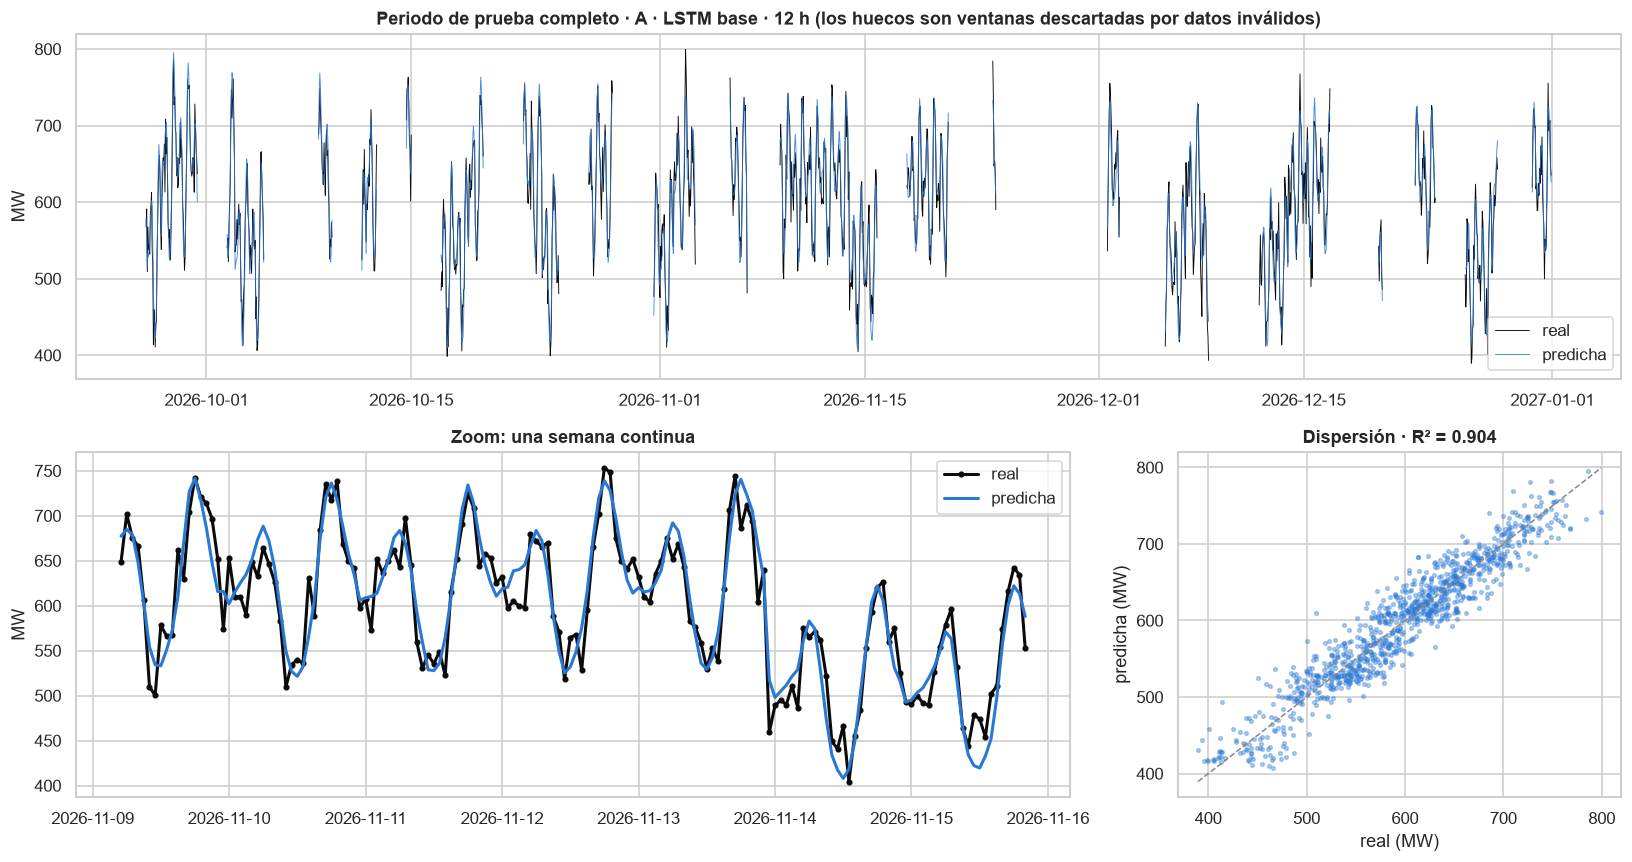

In [22]:
it, p = pred_test[MEJOR]
ts = df.timestamp.to_numpy()[it]; yr = dem_real[it]
fig = plt.figure(figsize=(15, 8))
g = fig.add_gridspec(2, 3)
a0 = fig.add_subplot(g[0, :])
tf_, yr_f, p_f = con_huecos(it, yr, p)
a0.plot(tf_, yr_f, color=TINTA, lw=.6, label="real")
a0.plot(tf_, p_f, color=COLOR[sel["arq"]], lw=.6, alpha=.85, label="predicha")
a0.set_title(f"Periodo de prueba completo · {NOMBRE[sel['arq']]} · {sel['ventana']} h "
             f"(los huecos son ventanas descartadas por datos inválidos)"); a0.set_ylabel("MW"); a0.legend()

# Zoom: la semana continua más larga del conjunto común
corte = np.where(np.diff(it) > 1)[0]
tramos = np.split(np.arange(len(it)), corte + 1)
tramo = max(tramos, key=len)[:168]
a1 = fig.add_subplot(g[1, :2])
a1.plot(ts[tramo], yr[tramo], color=TINTA, lw=2, marker="o", ms=3, label="real")
a1.plot(ts[tramo], p[tramo], color=COLOR[sel["arq"]], lw=2, label="predicha")
a1.set_title("Zoom: una semana continua"); a1.set_ylabel("MW"); a1.legend()

a2 = fig.add_subplot(g[1, 2])
a2.scatter(yr, p, s=6, alpha=.35, color=COLOR[sel["arq"]])
lim = [min(yr.min(), p.min()), max(yr.max(), p.max())]
a2.plot(lim, lim, color=GRIS, ls="--", lw=1)
a2.set_xlabel("real (MW)"); a2.set_ylabel("predicha (MW)")
a2.set_title(f"Dispersión · R² = {r2_score(yr, p):.3f}")
plt.tight_layout(); plt.show()

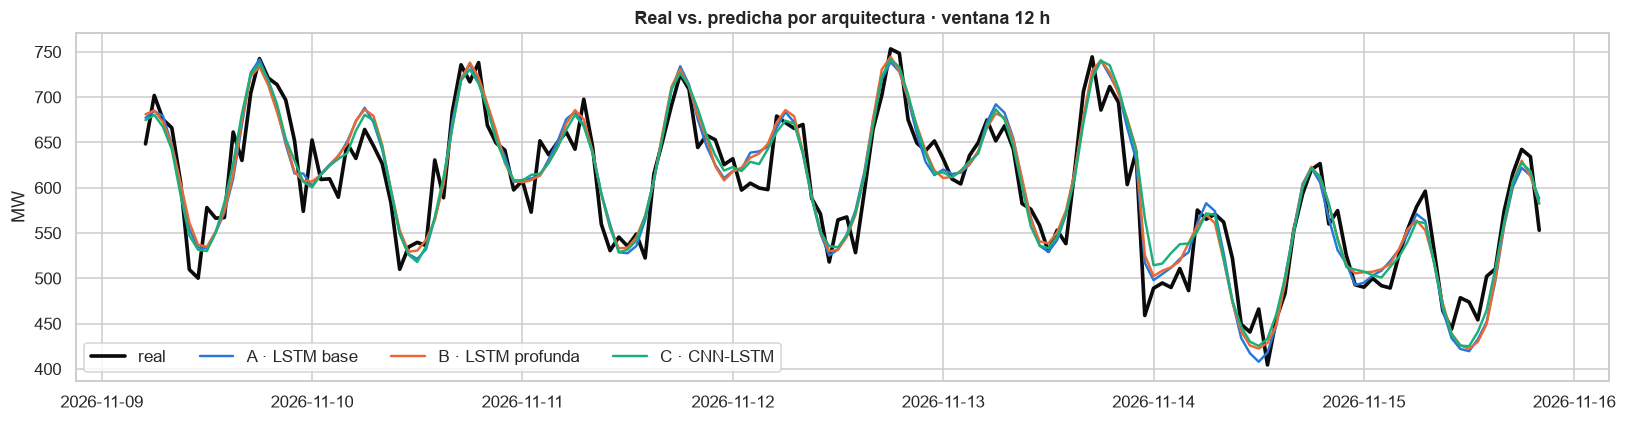

In [23]:
# Las tres arquitecturas sobre la misma semana (ventana del modelo seleccionado)
n_sel = sel["ventana"]
plt.figure(figsize=(15, 4))
plt.plot(ts[tramo], yr[tramo], color=TINTA, lw=2.4, label="real")
for arq in "ABC":
    i2, p2 = pred_test[f"{arq}_w{n_sel}"]
    pos = np.searchsorted(i2, it[tramo])
    plt.plot(ts[tramo], p2[pos], color=COLOR[arq], lw=1.6, label=NOMBRE[arq])
plt.title(f"Real vs. predicha por arquitectura · ventana {n_sel} h"); plt.ylabel("MW"); plt.legend(ncol=4)
plt.tight_layout(); plt.show()

### 8.3 Error de predicción

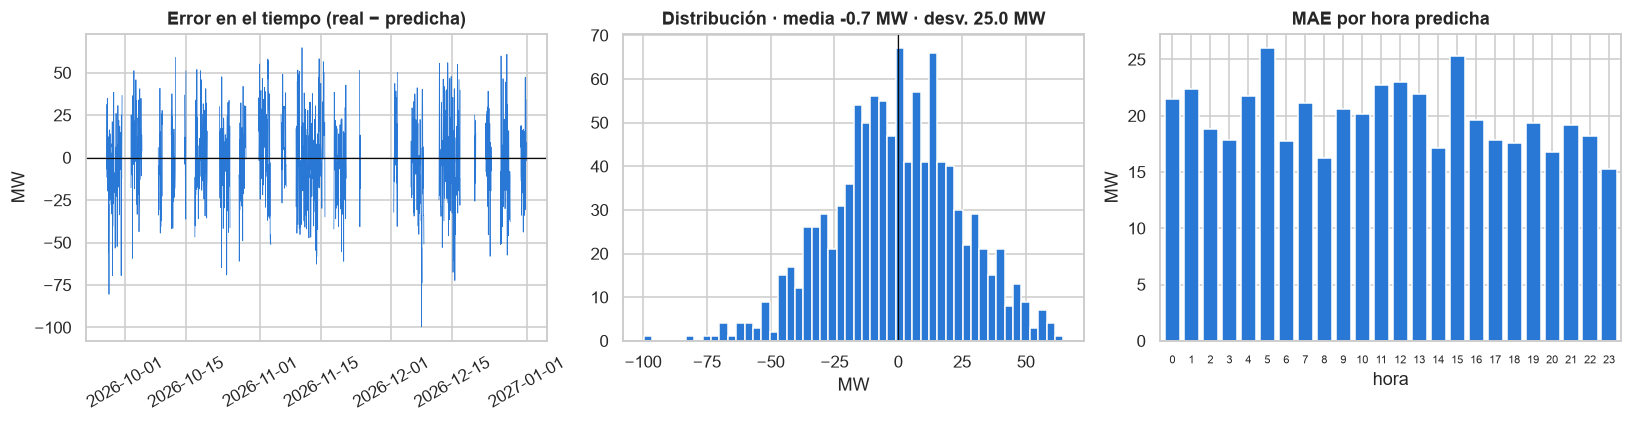

Sesgo medio: -0.70 MW | |error| < 25 MW en el 68.9% de las horas | percentil 95 de |error|: 49.0 MW


In [24]:
err = yr - p
hora_t1 = (df.hora.to_numpy()[it] + 1) % 24          # hora que se está prediciendo
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
tf_, err_f = con_huecos(it, err)
ax[0].plot(tf_, err_f, color=COLOR[sel["arq"]], lw=.5); ax[0].axhline(0, color=TINTA, lw=.8)
ax[0].set_title("Error en el tiempo (real − predicha)"); ax[0].set_ylabel("MW")
ax[0].tick_params(axis="x", rotation=30)
ax[1].hist(err, bins=50, color=COLOR[sel["arq"]], edgecolor="#fcfcfb")
ax[1].axvline(0, color=TINTA, lw=.8)
ax[1].set_title(f"Distribución · media {err.mean():.1f} MW · desv. {err.std():.1f} MW"); ax[1].set_xlabel("MW")
pd.Series(np.abs(err)).groupby(hora_t1).mean().plot.bar(ax=ax[2], color=COLOR[sel["arq"]], width=.8)
ax[2].set_title("MAE por hora predicha"); ax[2].set_xlabel("hora"); ax[2].set_ylabel("MW")
ax[2].tick_params(axis="x", rotation=0, labelsize=7)
plt.tight_layout(); plt.show()
print(f"Sesgo medio: {err.mean():.2f} MW | |error| < 25 MW en el {(np.abs(err) < 25).mean():.1%} de las horas "
      f"| percentil 95 de |error|: {np.percentile(np.abs(err), 95):.1f} MW")

## 9. Sobreajuste y generalización

Se compara el error de cada modelo en entrenamiento, validación y prueba (cada uno sobre sus propias ventanas válidas). Si el error de entrenamiento es mucho menor que el de validación/prueba, el modelo memorizó en lugar de generalizar.

In [25]:
filas = []
for clave in modelos:
    r = info_ent[clave]; f = {"Modelo": NOMBRE[r["arq"]], "Ventana": r["ventana"]}
    for conj, eti in [("entrenamiento", "train"), ("validación", "val"), ("prueba", "test")]:
        i3, p3 = predecir(clave, conj)
        f[f"RMSE {eti}"] = np.sqrt(mean_squared_error(dem_real[i3], p3))
    f["test/train"] = f["RMSE test"] / f["RMSE train"]
    filas.append(f)
sobreaj = pd.DataFrame(filas)
sobreaj.style.format(precision=2).background_gradient(subset=["test/train"], cmap="Blues", vmin=1.0, vmax=1.35).hide(axis="index")

Modelo,Ventana,RMSE train,RMSE val,RMSE test,test/train
A · LSTM base,12,23.32,25.43,25.01,1.07
A · LSTM base,24,24.08,26.08,25.71,1.07
A · LSTM base,48,23.96,26.31,26.80,1.12
B · LSTM profunda,12,23.95,25.53,24.74,1.03
B · LSTM profunda,24,24.92,26.36,25.78,1.03
B · LSTM profunda,48,24.46,26.81,26.10,1.07
C · CNN-LSTM,12,23.95,25.81,25.03,1.04
C · CNN-LSTM,24,24.12,26.41,25.83,1.07
C · CNN-LSTM,48,24.45,26.70,27.29,1.12


**Lectura.** El cociente RMSE prueba / entrenamiento está entre **1.03 y 1.12**: el error fuera de la muestra es apenas 3-12 % mayor que dentro, así que **no hay sobreajuste relevante** y los modelos generalizan a un periodo (sept-dic 2026) que nunca vieron. Los modelos **con Dropout (B, C) tienen las brechas más bajas** (1.03-1.07 en 12-24 h), y las ventanas de 48 h las más altas (1.07-1.12), coherente con que tienen menos muestras para la misma cantidad de parámetros. Validación y prueba quedan muy cerca, señal de que la validación fue un buen estimador para elegir el modelo.

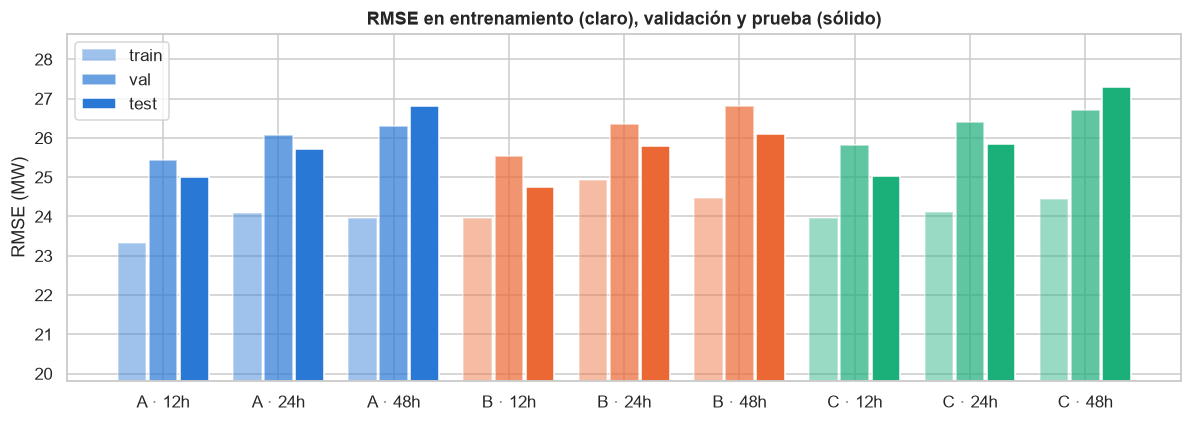

In [26]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(sobreaj)); w = .27
for k, (col, alpha) in enumerate([("RMSE train", .45), ("RMSE val", .7), ("RMSE test", 1)]):
    ax.bar(x + (k - 1) * w, sobreaj[col], w * .92, alpha=alpha,
           color=[COLOR[m[0]] for m in sobreaj.Modelo], label=col.replace("RMSE ", ""))
ax.set_xticks(x, [f"{m[0]} · {v}h" for m, v in zip(sobreaj.Modelo, sobreaj.Ventana)])
ax.set_ylabel("RMSE (MW)"); ax.set_title("RMSE en entrenamiento (claro), validación y prueba (sólido)")
ax.set_ylim(sobreaj[["RMSE train", "RMSE val", "RMSE test"]].min().min() * .85, None)
ax.legend(); plt.tight_layout(); plt.show()

## 10. Experimentos de control: Dropout, Early Stopping y número de neuronas

Para responder con evidencia (y no solo con teoría) las preguntas 4, 5 y 6, se entrenan variantes controladas con la ventana de 12 h, cambiando **un solo factor** a la vez:

| Experimento | Variante | Se compara con |
|---|---|---|
| Dropout | B sin Dropout (`dropout=0`) | B con Dropout 0.2 |
| Early Stopping | A entrenada 150 épocas fijas, sin Early Stopping | A con Early Stopping |
| Neuronas | A con 8 y con 128 unidades | A con 32 unidades |

In [27]:
def entrenar_variante(constructor, n=12, early=True, epocas=80):
    keras.utils.set_random_seed(SEED)
    Xtr, ytr, _ = datos[n]["entrenamiento"]; Xva, yva, _ = datos[n]["validación"]
    m = constructor(n, N_FEAT)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    cb = ([keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)]
          if early else [])
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epocas, batch_size=64, verbose=0, callbacks=cb)
    Xte, _, ite = datos[n]["prueba"]
    p = esc.y_inverso(m.predict(Xte, batch_size=512, verbose=0).ravel())
    ptr = esc.y_inverso(m.predict(Xtr, batch_size=512, verbose=0).ravel())
    _, _, itr = datos[n]["entrenamiento"]
    return {"hist": h.history, "parametros": m.count_params(), "epocas": len(h.history["loss"]),
            "RMSE train": np.sqrt(mean_squared_error(dem_real[itr], ptr)),
            "RMSE test": np.sqrt(mean_squared_error(dem_real[ite], p)), "R² test": r2_score(dem_real[ite], p)}

RUTA_EXP = "artefactos/experimentos.joblib"
if REENTRENAR or not os.path.exists(RUTA_EXP):
    exp = {
        "B sin Dropout":          entrenar_variante(lambda n, f: mdl.modelo_B(n, f, dropout=0.0)),
        "A sin Early Stopping":   entrenar_variante(mdl.modelo_A, early=False, epocas=150),
        "A con 8 neuronas":       entrenar_variante(lambda n, f: mdl.modelo_A(n, f, unidades=8)),
        "A con 128 neuronas":     entrenar_variante(lambda n, f: mdl.modelo_A(n, f, unidades=128)),
    }
    joblib.dump(exp, RUTA_EXP)
else:
    exp = joblib.load(RUTA_EXP); print("Experimentos cargados desde disco.")

# Referencias ya entrenadas (ventana 12 h)
def ref(clave):
    _, _, itr = datos[12]["entrenamiento"]
    ptr = esc.y_inverso(modelos[clave].predict(datos[12]["entrenamiento"][0], batch_size=512, verbose=0).ravel())
    ite, p = predecir(clave, "prueba")
    return {"hist": historiales[clave], "parametros": modelos[clave].count_params(),
            "epocas": info_ent[clave]["epocas_ejecutadas"],
            "RMSE train": np.sqrt(mean_squared_error(dem_real[itr], ptr)),
            "RMSE test": np.sqrt(mean_squared_error(dem_real[ite], p)), "R² test": r2_score(dem_real[ite], p)}
exp_todos = {"A con 32 neuronas + Early Stopping (referencia)": ref("A_w12"),
             "B con Dropout 0.2 (referencia)": ref("B_w12"), **exp}
tab_exp = pd.DataFrame({k: {c: v[c] for c in ["parametros", "epocas", "RMSE train", "RMSE test", "R² test"]}
                        for k, v in exp_todos.items()}).T
tab_exp["brecha test−train"] = tab_exp["RMSE test"] - tab_exp["RMSE train"]
tab_exp.astype(float).round({"parametros": 0, "epocas": 0, "RMSE train": 2, "RMSE test": 2,
                             "R² test": 4, "brecha test−train": 2})

Experimentos cargados desde disco.


,parametros,epocas,RMSE train,RMSE test,R² test,brecha test−train
A con 32 neuronas + Early Stopping (referencia),6177.0,60.0,23.32,25.01,0.9076,1.69
B con Dropout 0.2 (referencia),33441.0,54.0,23.95,24.74,0.9096,0.79
B sin Dropout,33441.0,41.0,23.23,25.26,0.9058,2.03
A sin Early Stopping,6177.0,150.0,21.08,28.87,0.8769,7.79
A con 8 neuronas,777.0,80.0,24.80,25.22,0.9061,0.42
A con 128 neuronas,73857.0,41.0,22.88,24.92,0.9083,2.04


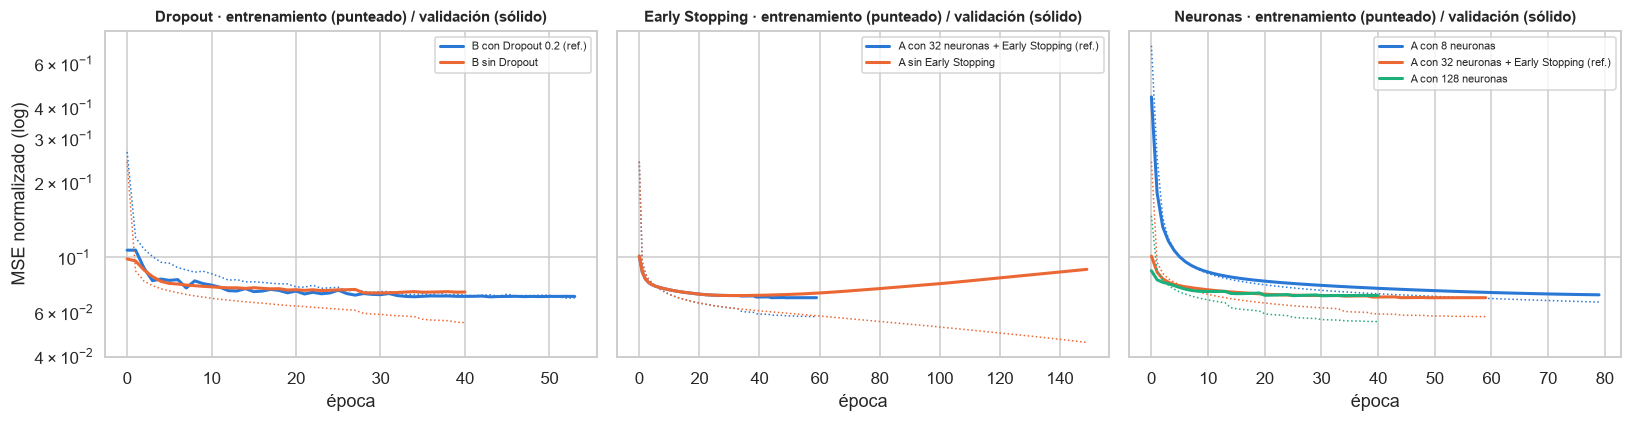

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
pares = [("Dropout", ["B con Dropout 0.2 (referencia)", "B sin Dropout"]),
         ("Early Stopping", ["A con 32 neuronas + Early Stopping (referencia)", "A sin Early Stopping"]),
         ("Neuronas", ["A con 8 neuronas", "A con 32 neuronas + Early Stopping (referencia)", "A con 128 neuronas"])]
paleta = ["#2a78d6", "#eb6834", "#1baf7a"]
for a, (tit, claves) in zip(ax, pares):
    for c, k in zip(paleta, claves):
        h = exp_todos[k]["hist"]
        a.plot(h["loss"], color=c, lw=1, ls=":")
        a.plot(h["val_loss"], color=c, lw=2, label=k.replace(" (referencia)", " (ref.)"))
    a.set_yscale("log"); a.set_title(f"{tit} · entrenamiento (punteado) / validación (sólido)", fontsize=10)
    a.set_xlabel("época"); a.legend(fontsize=7.5)
ax[0].set_ylabel("MSE normalizado (log)")
plt.tight_layout(); plt.show()

**Lectura de los experimentos de control**

* **Sin Early Stopping** (150 épocas): el error de entrenamiento sigue bajando (23.3 → 21.1 MW) pero la validación **sube** desde la época ~35 y el RMSE de prueba empeora de 25.0 a **28.9 MW** (+15 %). Es sobreajuste de libro: la red empieza a memorizar ruido. Early Stopping lo evita deteniéndose en el mínimo de validación.
* **Sin Dropout** (B): entrena más rápido y baja más el error de entrenamiento, pero la brecha prueba-entrenamiento pasa de 0.8 a 2.0 MW y el RMSE de prueba empeora (24.7 → 25.3 MW). El Dropout actúa como regularizador.
* **Neuronas:** con **8 neuronas (777 parámetros)** el RMSE de prueba es 25.2 MW; con 32, 25.0; con **128 (73 857 parámetros, 95× más)**, 24.9. Multiplicar los parámetros casi no mejora y aumenta la brecha de generalización (0.4 → 2.0 MW). **Más neuronas no implica mejores resultados**: el límite lo pone la información disponible en los datos, no la capacidad del modelo.

In [29]:
# Guardar la configuración del modelo seleccionado para la app web
import shutil
cfg = {"modelo": MEJOR, "arquitectura": NOMBRE[sel["arq"]], "ventana": sel["ventana"],
       "features": pp.FEATURES, "escalador": esc.a_dict(),
       "metricas_prueba": {k: float(v) for k, v in tabla[(tabla.Modelo == NOMBRE[sel["arq"]]) &
                           (tabla.Ventana == sel["ventana"])].iloc[0][["MAE", "RMSE", "MAPE", "R²"]].items()}}
shutil.copy(f"modelos/{MEJOR}.keras", "modelos/modelo_produccion.keras")
with open("artefactos/config_app.json", "w", encoding="utf-8") as fh:
    json.dump(cfg, fh, ensure_ascii=False, indent=2)
tabla.to_csv("artefactos/tabla_resultados.csv", index=False)
print(json.dumps({k: v for k, v in cfg.items() if k != "escalador"}, ensure_ascii=False, indent=2))

{
  "modelo": "A_w12",
  "arquitectura": "A · LSTM base",
  "ventana": 12,
  "features": [
    "demanda_mw",
    "temperatura_c",
    "humedad_pct",
    "viento_kmh",
    "radiacion_wm2",
    "precipitacion_mm",
    "precio_kwh",
    "hora_sin",
    "hora_cos",
    "dia_sin",
    "dia_cos",
    "mes_sin",
    "mes_cos",
    "fin_semana",
    "festivo"
  ],
  "metricas_prueba": {
    "MAE": 19.856540695660016,
    "RMSE": 24.991616708893215,
    "MAPE": 3.4289498140281878,
    "R²": 0.9037199022694633
  }
}


## 11. Evidencia adicional para el análisis

### 11.1 ¿Aporta algo la LSTM frente a un modelo lineal?
Se entrena una regresión lineal (Ridge) sobre exactamente las mismas ventanas de 12 h, aplanadas (12 × 15 = 180 entradas). Si la LSTM no la superara, su complejidad no estaría justificada.

In [30]:
from sklearn.linear_model import Ridge
Xtr12, ytr12, _ = datos[12]["entrenamiento"]
ridge = Ridge(alpha=1.0).fit(Xtr12.reshape(len(Xtr12), -1), ytr12)
Xte12, _, ite12 = datos[12]["prueba"]
m_comun = np.isin(ite12, idx_comun["prueba"])
p_ridge = esc.y_inverso(ridge.predict(Xte12[m_comun].reshape(m_comun.sum(), -1)))
it_c = ite12[m_comun]
comp = pd.DataFrame({
    "Persistencia": metricas(dem_real[it_c], df.demanda_mw.to_numpy()[it_c]),
    "Regresión lineal (Ridge, 12 h)": metricas(dem_real[it_c], p_ridge),
    "LSTM A (12 h)": metricas(dem_real[it_c], pred_test["A_w12"][1]),
}).T
comp.round({"MAE": 2, "MSE": 1, "RMSE": 2, "MAPE": 2, "R²": 4})

,MAE,MSE,RMSE,MAPE,R²
Persistencia,35.50,1963.3,44.31,6.07,0.6974
"Regresión lineal (Ridge, 12 h)",22.53,874.2,29.57,3.90,0.8652
LSTM A (12 h),19.86,624.6,24.99,3.43,0.9037


### 11.2 Importancia de las variables (permutación)
Para cada variable se **desordenan sus valores entre las muestras de prueba** (en todos los pasos de la ventana) y se mide cuánto empeora el RMSE del modelo seleccionado. Si el modelo depende de esa variable, el error sube mucho; si no la usa, casi no cambia. Las codificaciones seno/coseno de una misma variable se permutan juntas. Se promedian 3 repeticiones.

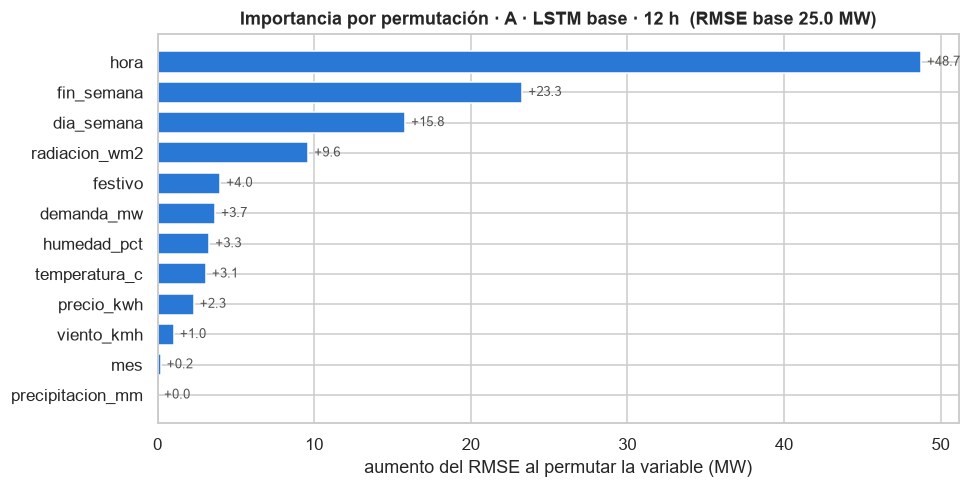

In [31]:
GRUPOS = {"demanda_mw": [0], "temperatura_c": [1], "humedad_pct": [2], "viento_kmh": [3],
          "radiacion_wm2": [4], "precipitacion_mm": [5], "precio_kwh": [6], "hora": [7, 8],
          "dia_semana": [9, 10], "mes": [11, 12], "fin_semana": [13], "festivo": [14]}
mod_sel = modelos[MEJOR]
n_sel = sel["ventana"]
Xte_s, _, ite_s = datos[n_sel]["prueba"]
y_s = dem_real[ite_s]
pred_s = lambda Xp: esc.y_inverso(mod_sel.predict(Xp, batch_size=1024, verbose=0).ravel())
rmse_base = np.sqrt(mean_squared_error(y_s, pred_s(Xte_s)))
rng = np.random.default_rng(0)
imp = {}
for g, cols in GRUPOS.items():
    subidas = []
    for _ in range(3):
        Xp = Xte_s.copy(); perm = rng.permutation(len(Xp))
        Xp[:, :, cols] = Xte_s[perm][:, :, cols]
        subidas.append(np.sqrt(mean_squared_error(y_s, pred_s(Xp))) - rmse_base)
    imp[g] = np.mean(subidas)
imp = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(imp.index, imp.values, color="#2a78d6", height=.7)
for yv, v in enumerate(imp.values):
    ax.text(v + .4, yv, f"+{v:.1f}", va="center", fontsize=8.5, color="#52514e")
ax.set_xlabel("aumento del RMSE al permutar la variable (MW)")
ax.set_title(f"Importancia por permutación · {NOMBRE[sel['arq']]} · {n_sel} h  (RMSE base {rmse_base:.1f} MW)")
plt.tight_layout(); plt.show()

### 11.3 ¿Dónde se equivoca más el modelo?

In [32]:
it_s1 = np.minimum(ite_s + 1, len(df) - 1)            # la hora que se está prediciendo (t+1)
err_abs = np.abs(y_s - pred_s(Xte_s))
grupos_err = pd.DataFrame({
    "MAE (MW)": [err_abs[df.festivo.to_numpy()[it_s1] == 1].mean(), err_abs[df.festivo.to_numpy()[it_s1] == 0].mean(),
                 err_abs[df.fin_semana.to_numpy()[it_s1] == 1].mean(), err_abs[df.fin_semana.to_numpy()[it_s1] == 0].mean()],
    "horas": [(df.festivo.to_numpy()[it_s1] == 1).sum(), (df.festivo.to_numpy()[it_s1] == 0).sum(),
              (df.fin_semana.to_numpy()[it_s1] == 1).sum(), (df.fin_semana.to_numpy()[it_s1] == 0).sum()]},
    index=["festivo", "no festivo", "fin de semana", "día laboral"])
print(f"Horas con |error| > 50 MW: {(err_abs > 50).mean():.1%}")
print(f"Festivos en entrenamiento: {df.iloc[:i_tr].festivo.sum()} horas "
      f"({df.iloc[:i_tr][df.iloc[:i_tr].festivo == 1].timestamp.dt.date.nunique()} días)")
grupos_err.round(2)

Horas con |error| > 50 MW: 4.9%
Festivos en entrenamiento: 192 horas (8 días)


,MAE (MW),horas
festivo,34.84,38
no festivo,19.64,2055
fin de semana,20.01,621
día laboral,19.87,1472


## 12. Preguntas de análisis

### 1. ¿Por qué LSTM es apropiada para este problema?
La demanda eléctrica es una **serie temporal**: el valor de la próxima hora depende de lo que pasó en las horas anteriores (inercia del consumo, rampas de la mañana y la tarde, el ciclo diario). Una red densa trata cada entrada como independiente y no tiene noción de orden; una RNN simple sí la tiene, pero sufre de **desvanecimiento del gradiente** y "olvida" lo ocurrido hace muchas horas.

La LSTM resuelve esto con una **celda de memoria** y tres **compuertas** (olvido, entrada y salida) que aprenden qué información conservar, qué añadir y qué exponer en cada paso. Además:
* acepta entradas **multivariadas** (demanda, clima, precio y calendario a la vez) y aprende relaciones **no lineales** entre ellas (p. ej. la temperatura sube la demanda distinto de día que de noche);
* lee la ventana **en orden**, así que puede usar la forma de la curva reciente (si viene subiendo o bajando), no solo su nivel.

**Evidencia (sección 11.1):** sobre los mismos datos, la LSTM A obtiene RMSE ≈ 25 MW frente a ≈ 44 MW de la persistencia y supera también a una regresión lineal que ve exactamente la misma ventana (RMSE 29.6 MW, R² 0.87 vs 25.0 MW y R² 0.90 de la LSTM: **15 % menos error**). La diferencia con el modelo lineal es lo que aportan la no linealidad y la memoria.

### 2. ¿Qué efecto tiene cambiar la ventana temporal?
En las **tres arquitecturas**, la ventana de **12 h fue la mejor y la de 48 h la peor** (RMSE en prueba común: A 25.0 → 25.5 → 26.8 MW; B 24.8 → 25.7 → 26.1; C 25.3 → 25.5 → 27.3). Hay un compromiso:

* **Ventana más larga** = más contexto, pero también más entradas que procesar, un gradiente que debe propagarse por más pasos y **menos muestras de entrenamiento** (cada dato inválido descarta *n* ventanas: 9 686 muestras con 12 h vs 4 504 con 48 h). Más parámetros efectivos por muestra → peor generalización (cociente prueba/entrenamiento 1.07 con 12 h vs 1.12 con 48 h en A y C).
* **Ventana más corta** = menos contexto, pero aquí no hace falta más: el **ciclo diario** ya llega al modelo mediante la codificación cíclica de `hora` y `dia_semana`, y la información sobre el nivel actual de la demanda está en las últimas horas. Por eso 12 h basta.

Una ventana demasiado corta (p. ej. 1-3 h) perdería la tendencia reciente; la elección óptima depende del problema y se debe validar, como se hizo aquí.

### 3. ¿Existe sobreajuste?
**No hay sobreajuste relevante** en los modelos finales:
* El RMSE de prueba es solo **3-12 % mayor** que el de entrenamiento (cociente 1.03-1.12, sección 9), y validación y prueba quedan muy cerca entre sí.
* Las curvas de pérdida (sección 6) no muestran la "U" típica: la validación se estabiliza y Early Stopping corta antes de que empiece a subir.
* La A sin regularización muestra una brecha pequeña (pérdida de entrenamiento que sigue bajando mientras la de validación se aplana): un **sobreajuste leve y controlado**.

El experimento de control confirma que el riesgo existía: **la misma A entrenada 150 épocas sin Early Stopping sí sobreajusta** (RMSE de entrenamiento 21.1 MW, pero de prueba 28.9 MW, un 15 % peor que con Early Stopping). Es decir, el sobreajuste se evitó gracias a las decisiones de entrenamiento, no porque fuera imposible.

### 4. ¿Qué es y qué efecto tiene Dropout?
**Dropout** es una técnica de regularización que, **durante el entrenamiento**, apaga aleatoriamente una fracción *p* de las neuronas en cada paso (aquí *p* = 0.2, el 20 %) y escala las restantes para compensar. Al predecir se desactiva y se usa la red completa. Efectos:
* Obliga a que ninguna neurona dependa de otras específicas (evita la **co-adaptación**) y a aprender representaciones redundantes y robustas.
* Equivale a entrenar un **conjunto de muchas subredes** que comparten pesos y promediarlas al predecir.
* Reduce el sobreajuste a cambio de un entrenamiento algo más lento y ruidoso.

**Evidencia (sección 10):** quitar el Dropout a B redujo el error de entrenamiento pero **amplió la brecha prueba-entrenamiento de 0.8 a 2.0 MW** y empeoró el RMSE de prueba (24.7 → 25.3 MW). También explica por qué en B y C la pérdida de validación queda *por debajo* de la de entrenamiento: la de entrenamiento se mide con neuronas apagadas.

### 5. ¿Qué es y qué efecto tiene Early Stopping?
**Early Stopping** vigila una métrica en validación (aquí `val_loss`) y **detiene el entrenamiento cuando deja de mejorar** durante un número de épocas (paciencia = 10). Con `restore_best_weights=True` devuelve los pesos de la mejor época, no los de la última. Efectos:
* **Evita el sobreajuste:** corta justo cuando la red empieza a memorizar el ruido de entrenamiento.
* **Elige automáticamente el número de épocas** (columna *Épocas* de la tabla: entre 42 y 66, con la mejor 10 épocas antes) y ahorra tiempo de cómputo.

**Evidencia (sección 10):** sin Early Stopping, a partir de la época ~35 la pérdida de validación **sube** mientras la de entrenamiento sigue bajando, y el RMSE de prueba empeora de **25.0 a 28.9 MW**.

### 6. ¿Más neuronas implican necesariamente mejores resultados?
**No.** Lo muestran dos comparaciones:
* **Experimento de neuronas (A, 12 h):** 8 neuronas (777 parámetros) → RMSE 25.2 MW; 32 neuronas (6 177) → 25.0 MW; 128 neuronas (73 857, **95× más**) → 24.9 MW. La mejora es de apenas 0.3 MW y la brecha de generalización crece de 0.4 a 2.0 MW.
* **Entre arquitecturas:** B tiene 5× más parámetros que A y queda prácticamente empatada (24.8 vs 25.0 MW con 12 h, y peor que A en validación).

Más capacidad solo ayuda mientras el modelo esté **subajustado**. Una vez que capta los patrones reales, el error restante es ruido que ninguna red puede predecir, y la capacidad extra se usa para memorizar ese ruido (sobreajuste), además de costar más cómputo y datos. El tamaño adecuado se encuentra validando, no maximizando.

### 7. ¿Qué modelo recomendaría para producción y por qué?
Se recomienda **A · LSTM base con ventana de 12 h**:
* **Fue el mejor en validación**, el criterio correcto de selección (el conjunto de prueba se reservó para estimar el error final: **MAE 19.9 MW, RMSE 25.0 MW, MAPE 3.4 %, R² 0.90**).
* Es el **más simple y ligero** (6 177 parámetros): inferencia instantánea, fácil de reentrenar, mantener y explicar.
* B quedó 0.2 MW mejor en prueba, una diferencia dentro del ruido que no justifica 5× más parámetros ni el doble de tiempo de entrenamiento. Ante un empate, el principio de parsimonia favorece al modelo simple.
* La ventana de 12 h fue la mejor en todas las arquitecturas y, en operación, **requiere solo 12 horas de historia válida**: es menos probable que un dato faltante impida generar la predicción que con 24 o 48 h.

En producción debería acompañarse de monitoreo del error, validación de las entradas con las mismas reglas de limpieza y reentrenamiento periódico.

### 8. ¿Qué variables pueden influir más en la demanda?
Según la **importancia por permutación** (sección 11.2), lo que más usa el modelo es el **calendario**: la **hora del día** (de lejos la más importante), el **fin de semana** y el **día de la semana**. Después vienen la **radiación solar**, los **festivos**, la **demanda reciente** y las variables climáticas (**humedad, temperatura**) y el **precio**. **Viento, mes y precipitación** casi no aportan.

Esto coincide con el análisis exploratorio: la demanda tiene un perfil diario muy marcado, baja en fin de semana (correlación −0.49) y se relaciona con la temperatura (+0.48) y la radiación (−0.50).

Dos matices:
* La importancia por permutación **no es causalidad**, y las variables correlacionadas se reparten la importancia. Por ejemplo, la radiación está muy ligada a la hora del día.
* La demanda reciente aparece más abajo de lo que su correlación sugiere (0.88) porque buena parte de esa información ya está contenida en el calendario y el clima: si se desordena la demanda, el modelo aún puede reconstruir el perfil esperado a partir de la hora y el día.

`mes` apenas importa porque el conjunto de prueba solo cubre septiembre-diciembre y la estacionalidad ya está representada por la temperatura y la radiación.

### 9. ¿Qué limitaciones tiene el modelo?
* **Festivos:** el error medio en horas festivas es **≈ 35 MW, casi el doble** que en días normales (≈ 20 MW). Hay muy pocos ejemplos: solo **8 días festivos (192 horas)** en el periodo de entrenamiento, así que el modelo no aprende bien su comportamiento particular.
* **Datos faltantes en operación:** como no se imputa, si alguna de las últimas 12 horas tiene un valor inválido **no se puede generar la predicción**. Un sistema real necesitaría un plan de contingencia (otro modelo, o alertar al operador).
* **Solo una hora adelante:** predice *t+1*. Para planear el día siguiente habría que predecir de forma recursiva (los errores se acumulan) o entrenar un modelo multi-horizonte.
* **Sin pronósticos exógenos:** usa clima observado hasta *t*, no pronósticos meteorológicos de *t+1*. Un cambio brusco del clima en la próxima hora no se anticipa.
* **Historia corta y estacionalidad anual poco vista:** dos años de datos implican pocos ciclos de cada mes, y la prueba (sept-dic 2026) no evalúa todas las estaciones.
* **Picos extremos:** ≈ 5 % de las horas tienen error > 50 MW, en general en cambios bruscos que el modelo suaviza (se ve en el zoom de la sección 8.2: la curva predicha es más suave que la real).
* **Predicción puntual sin incertidumbre:** entrega un único valor sin intervalo de confianza, útil saberlo para decisiones de despacho.
* **Deriva de los datos:** si cambian los patrones de consumo (nuevas industrias, tarifas, autogeneración solar), el modelo debe reentrenarse; los parámetros de normalización también quedan fijos al periodo de entrenamiento.

## 13. Conclusiones
1. Tras una limpieza estricta y justificada, **sin inventar valores**, y un esquema cronológico sin fuga de información, las LSTM predicen la demanda de la siguiente hora con **MAPE ≈ 3.4 % y R² ≈ 0.90** en un periodo nunca visto, un **43 % menos de error que la persistencia**.
2. La **ventana de 12 h** fue la mejor para las tres arquitecturas; ventanas más largas aportan poco contexto adicional y reducen las muestras disponibles.
3. Las diferencias entre arquitecturas son pequeñas: **la complejidad adicional (B, C) no se tradujo en mejoras relevantes**, así que se recomienda la LSTM base por simplicidad y robustez.
4. **Dropout y Early Stopping** fueron determinantes para evitar el sobreajuste, como demostraron los experimentos de control.
5. El modelo depende sobre todo del **calendario** (hora, fin de semana, día) y en segundo lugar del **clima** y la demanda reciente; su principal punto débil son los **festivos**.

## 14. Despliegue en una app web

El modelo seleccionado (**A · LSTM base, ventana 12 h**) se despliega en **Vercel** como una app web (carpeta `app_vercel/`):

* **Frontend** (`index.html`, `app.js`): permite ingresar las variables independientes (x) de las últimas 12 horas, ya sea cargándolas desde el histórico, escribiéndolas a mano o subiendo un CSV, y muestra la predicción de la demanda de la hora siguiente (y) con su rango típico de error, la gráfica y, si existe, el valor real.
* **API** (`api/predict.py`): función serverless de Python que valida las entradas con **las mismas reglas de limpieza** del notebook (si hay un valor faltante o fuera de rango, lo informa y no predice: no se inventan valores), construye las 15 variables por hora, normaliza con los parámetros de **entrenamiento** y ejecuta la LSTM.
* **Por qué NumPy y no TensorFlow en el servidor:** TensorFlow pesa más de 500 MB y supera el límite de las funciones serverless (250 MB). Como la arquitectura A tiene solo 6 177 parámetros, se exportan sus pesos a JSON y el paso hacia adelante de la LSTM (compuertas de entrada, olvido, candidata y salida) se implementa en NumPy. La celda siguiente verifica que ambas implementaciones dan el mismo resultado.

In [33]:
import exportar_modelo
modelo_prod, df_limpio = exportar_modelo.exportar()
dif = exportar_modelo.verificar(modelo_prod, df_limpio)

Verificación Keras vs. NumPy en 300 ventanas de prueba: diferencia máx. 0.0050 MW, media 0.0024 MW


Las diferencias son del orden de milésimas de MW, que corresponden al redondeo a 2 decimales que hace la API: **la app reproduce exactamente el modelo entrenado.**

Para probarla localmente: `python app_vercel/servidor_local.py` y abrir `http://localhost:8000`. Las instrucciones de despliegue están en el `README.md` del repositorio.